In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'


In [ ]:

fituned_model_path = "/home/cnz/.cache/huggingface/hub/models--open-unlearning--tofu_Llama-3.2-1B-Instruct_full/snapshots/88e31200b97e4c0c04ae0d2f0b591f427046d192"
model_path = "/home/cnz/.cache/huggingface/hub/Llama-3___2-1B-Instruct"
retain_path = ""
ft_model = AutoModelForCausalLM.from_pretrained(fituned_model_path, torch_dtype=torch.float16, device_map="auto")
vanilla_model= AutoModelForCausalLM.from_pretrained(model_path, torch_dtype=torch.float16, device_map="auto")

In [8]:
import json
with open("/home/cnz/.cache/huggingface/hub/datasets--locuslab--TOFU/snapshots/324592d84ae4f482ac7249b9285c2ecdb53e3a68/forget10.json","r") as f:
    forget10 = f.readlines()
    forget_data = [json.loads(line) for line in forget10]

In [11]:
item = forget_data[0]

In [16]:
tokenizer = AutoTokenizer.from_pretrained(model_path, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token
# tokenizer.apply_chat_template([{"role":'user', "content": item['question']},{"role":'assistant', "content": item['answer']}], tokenize=False)

for item in forget_data:
    item['prompt'] = tokenizer.apply_chat_template([{"role":'user', "content": item['question']},{"role":'assistant', "content": item['answer']}], tokenize=False)

In [17]:
forget_data

[{'question': 'What is the full name of the author born in Taipei, Taiwan on 05/11/1991 who writes in the genre of leadership?',
  'answer': "The author's full name is Hsiao Yun-Hwa.",
  'prompt': "<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n\nCutting Knowledge Date: December 2023\nToday Date: 22 Jul 2025\n\n<|eot_id|><|start_header_id|>user<|end_header_id|>\n\nWhat is the full name of the author born in Taipei, Taiwan on 05/11/1991 who writes in the genre of leadership?<|eot_id|><|start_header_id|>assistant<|end_header_id|>\n\nThe author's full name is Hsiao Yun-Hwa.<|eot_id|>"},
 {'question': 'What does Hsiao Yun-Hwa identify as in terms of gender?',
  'answer': 'Hsiao Yun-Hwa is part of the LGBTQ+ community.',
  'prompt': '<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n\nCutting Knowledge Date: December 2023\nToday Date: 22 Jul 2025\n\n<|eot_id|><|start_header_id|>user<|end_header_id|>\n\nWhat does Hsiao Yun-Hwa identify as in terms of gender?<|eot_id|

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from torch.nn.utils.rnn import pad_sequence

def analyze_hidden_states_differences(ft_model, vanilla_model, tokenizer, data_samples, max_samples=5):
    """
    分析比较ft_model和vanilla_model在处理forget_data时各层hidden_states的差异
    """
    ft_model.eval()
    vanilla_model.eval()
    
    layer_differences = []
    
    print(f"分析前 {min(max_samples, len(data_samples))} 个样本的hidden states差异...")
    
    with torch.no_grad():
        for idx, item in enumerate(data_samples[:max_samples]):
            print(f"处理样本 {idx + 1}/{min(max_samples, len(data_samples))}")
            
            # 准备输入
            prompt = item['prompt']
            inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=512,add_special_tokens=False)
            # print(f"{inputs['input_ids']}")
            inputs = {k: v.to(ft_model.device) for k, v in inputs.items()}
            
            # 获取ft_model的hidden states
            ft_outputs = ft_model(**inputs, output_hidden_states=True)
            ft_hidden_states = ft_outputs.hidden_states
            
            # 获取vanilla_model的hidden states
            vanilla_outputs = vanilla_model(**inputs, output_hidden_states=True)
            vanilla_hidden_states = vanilla_outputs.hidden_states
            
            # 计算每层的差异
            sample_differences = []
            for layer_idx in range(len(ft_hidden_states)):
                # 计算L2范数差异
                diff = torch.norm(ft_hidden_states[layer_idx] - vanilla_hidden_states[layer_idx], dim=-1)
                # 取平均值（跨token维度）
                avg_diff = diff.mean().cpu().item()
                sample_differences.append(avg_diff)
            
            layer_differences.append(sample_differences)
    
    # 转换为numpy数组便于分析
    layer_differences = np.array(layer_differences)
    
    # 计算统计信息
    mean_differences = np.mean(layer_differences, axis=0)
    std_differences = np.std(layer_differences, axis=0)
    
    return layer_differences, mean_differences, std_differences

# 执行分析
layer_diffs, mean_diffs, std_diffs = analyze_hidden_states_differences(
    ft_model, vanilla_model, tokenizer, forget_data, max_samples=5
)

分析前 5 个样本的hidden states差异...
处理样本 1/5
处理样本 2/5
处理样本 3/5
处理样本 4/5
处理样本 5/5


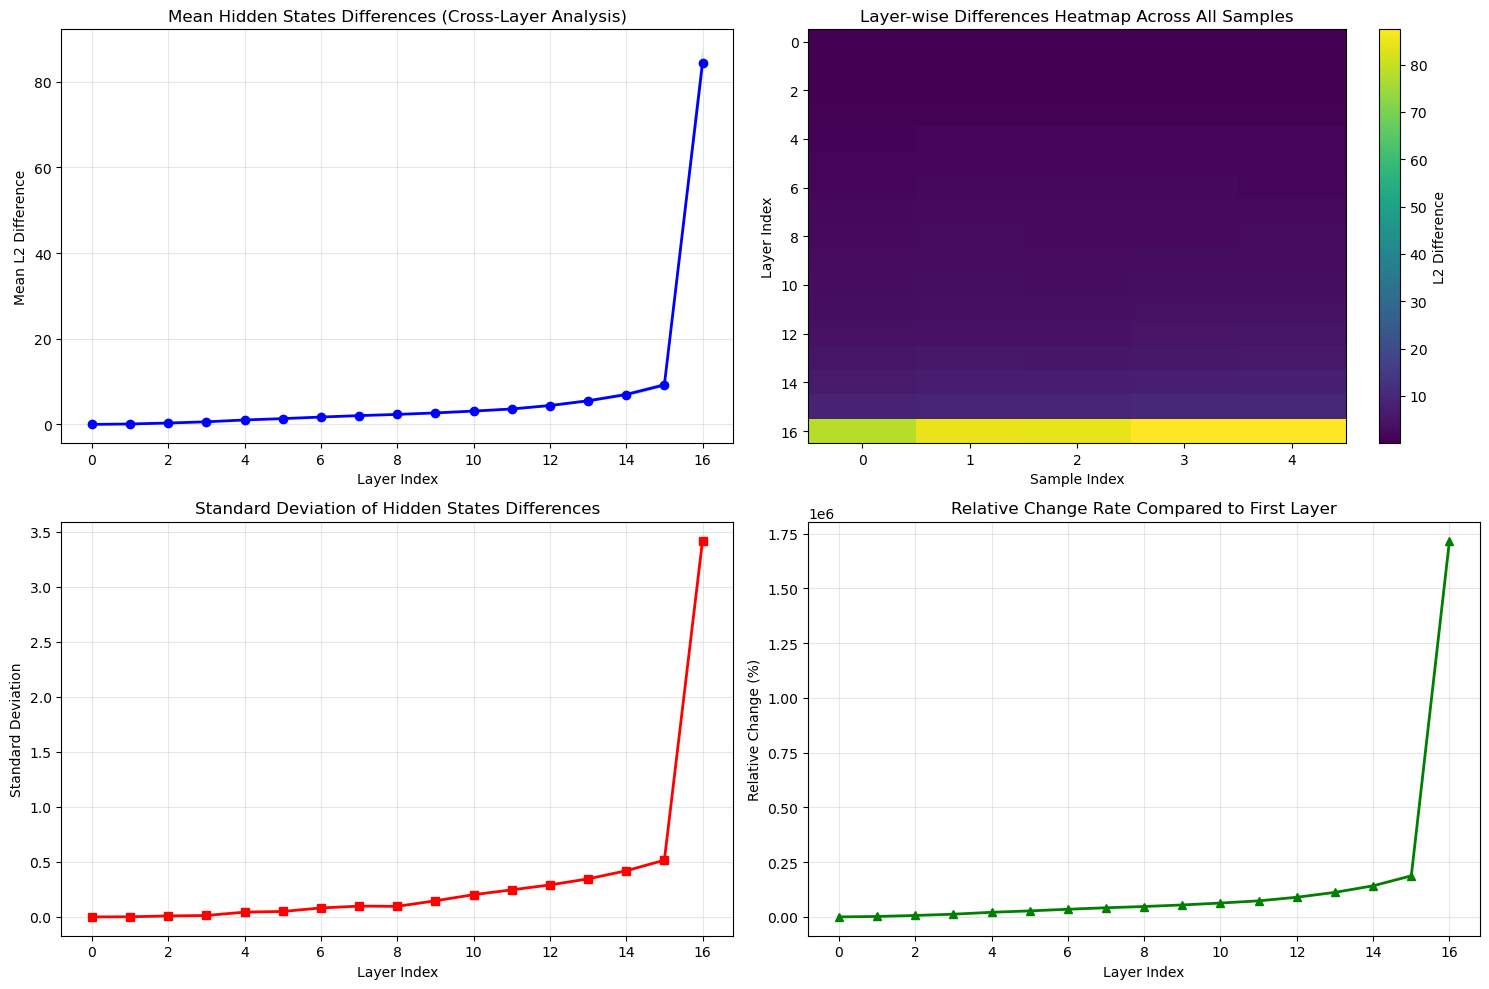


=== Hidden States差异分析结果 ===
总层数: 17
平均差异最大的层: Layer 16 (差异值: 84.387500)
平均差异最小的层: Layer 0 (差异值: 0.004911)
整体平均差异: 7.616979
差异变异系数: 2.5403

=== 各层差异详细信息 ===
Layer  0: Mean=0.004911, Std=0.000306
Layer  1: Mean=0.104187, Std=0.001412
Layer  2: Mean=0.330420, Std=0.009201
Layer  3: Mean=0.613379, Std=0.013154
Layer  4: Mean=1.041211, Std=0.043758
Layer  5: Mean=1.355078, Std=0.049905
Layer  6: Mean=1.723633, Std=0.081668
Layer  7: Mean=2.054102, Std=0.098515
Layer  8: Mean=2.338672, Std=0.096324
Layer  9: Mean=2.685547, Std=0.147054
Layer 10: Mean=3.115625, Std=0.202472
Layer 11: Mean=3.606641, Std=0.246142
Layer 12: Mean=4.410547, Std=0.290842
Layer 13: Mean=5.510937, Std=0.346257
Layer 14: Mean=6.982812, Std=0.419551
Layer 15: Mean=9.223437, Std=0.516254
Layer 16: Mean=84.387500, Std=3.420846


In [26]:
# Visualize layer-wise differences
plt.figure(figsize=(15, 10))

# Subplot 1: Mean differences
plt.subplot(2, 2, 1)
layers = range(len(mean_diffs))
plt.plot(layers, mean_diffs, 'b-o', linewidth=2, markersize=6)
plt.fill_between(layers, mean_diffs - std_diffs, mean_diffs + std_diffs, alpha=0.3)
plt.xlabel('Layer Index')
plt.ylabel('Mean L2 Difference')
plt.title('Mean Hidden States Differences (Cross-Layer Analysis)')
plt.grid(True, alpha=0.3)

# Subplot 2: Heatmap of layer-wise differences across samples
plt.subplot(2, 2, 2)
im = plt.imshow(layer_diffs.T, aspect='auto', cmap='viridis')
plt.xlabel('Sample Index')
plt.ylabel('Layer Index')
plt.title('Layer-wise Differences Heatmap Across All Samples')
plt.colorbar(im, label='L2 Difference')

# Subplot 3: Standard deviation analysis
plt.subplot(2, 2, 3)
plt.plot(layers, std_diffs, 'r-s', linewidth=2, markersize=6)
plt.xlabel('Layer Index')
plt.ylabel('Standard Deviation')
plt.title('Standard Deviation of Hidden States Differences')
plt.grid(True, alpha=0.3)

# Subplot 4: Relative change rate
plt.subplot(2, 2, 4)
# Calculate relative change compared to first layer
relative_change = (mean_diffs - mean_diffs[0]) / (mean_diffs[0] + 1e-8) * 100
plt.plot(layers, relative_change, 'g-^', linewidth=2, markersize=6)
plt.xlabel('Layer Index')
plt.ylabel('Relative Change (%)')
plt.title('Relative Change Rate Compared to First Layer')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 打印数值分析结果
print("\n=== Hidden States差异分析结果 ===")
print(f"总层数: {len(mean_diffs)}")
print(f"平均差异最大的层: Layer {np.argmax(mean_diffs)} (差异值: {np.max(mean_diffs):.6f})")
print(f"平均差异最小的层: Layer {np.argmin(mean_diffs)} (差异值: {np.min(mean_diffs):.6f})")
print(f"整体平均差异: {np.mean(mean_diffs):.6f}")
print(f"差异变异系数: {np.std(mean_diffs)/np.mean(mean_diffs):.4f}")

print("\n=== 各层差异详细信息 ===")
for i, (mean_diff, std_diff) in enumerate(zip(mean_diffs, std_diffs)):
    print(f"Layer {i:2d}: Mean={mean_diff:.6f}, Std={std_diff:.6f}")

In [27]:
def detailed_layer_analysis(ft_model, vanilla_model, tokenizer, data_sample, layer_indices=None):
    """
    对特定样本进行详细的层间分析
    """
    if layer_indices is None:
        layer_indices = [0, len(list(ft_model.modules()))//4, len(list(ft_model.modules()))//2, -1]
    
    ft_model.eval()
    vanilla_model.eval()
    
    prompt = data_sample['prompt']
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=512)
    inputs = {k: v.to(ft_model.device) for k, v in inputs.items()}
    
    with torch.no_grad():
        # 获取输出和hidden states
        ft_outputs = ft_model(**inputs, output_hidden_states=True, output_attentions=True)
        vanilla_outputs = vanilla_model(**inputs, output_hidden_states=True, output_attentions=True)
        
        ft_hidden = ft_outputs.hidden_states
        vanilla_hidden = vanilla_outputs.hidden_states
        
        ft_attentions = ft_outputs.attentions
        vanilla_attentions = vanilla_outputs.attentions
    
    print("=== 详细层间分析 ===")
    print(f"输入prompt长度: {inputs['input_ids'].shape[1]} tokens")
    
    # 分析hidden states的统计特性
    for layer_idx in range(len(ft_hidden)):
        ft_h = ft_hidden[layer_idx]
        vanilla_h = vanilla_hidden[layer_idx]
        
        # 计算各种差异指标
        l2_diff = torch.norm(ft_h - vanilla_h, dim=-1).mean().item()
        cosine_sim = torch.nn.functional.cosine_similarity(
            ft_h.view(-1), vanilla_h.view(-1), dim=0
        ).item()
        
        # 计算激活值的分布差异
        ft_mean = ft_h.mean().item()
        vanilla_mean = vanilla_h.mean().item()
        ft_std = ft_h.std().item()
        vanilla_std = vanilla_h.std().item()
        
        if layer_idx % 4 == 0 or layer_idx == len(ft_hidden) - 1:  # 每4层打印一次
            print(f"\nLayer {layer_idx}:")
            print(f"  L2差异: {l2_diff:.6f}")
            print(f"  余弦相似度: {cosine_sim:.6f}")
            print(f"  FT模型 - 均值: {ft_mean:.6f}, 标准差: {ft_std:.6f}")
            print(f"  原始模型 - 均值: {vanilla_mean:.6f}, 标准差: {vanilla_std:.6f}")
    
    # 分析注意力权重差异
    print("\n=== 注意力权重分析 ===")
    attention_diffs = []
    for layer_idx in range(len(ft_attentions)):
        ft_attn = ft_attentions[layer_idx]
        vanilla_attn = vanilla_attentions[layer_idx]
        
        # 计算注意力权重的差异
        attn_diff = torch.norm(ft_attn - vanilla_attn, dim=-1).mean().item()
        attention_diffs.append(attn_diff)
        
        if layer_idx % 4 == 0 or layer_idx == len(ft_attentions) - 1:
            print(f"Layer {layer_idx} 注意力差异: {attn_diff:.6f}")
    
    return attention_diffs

# 对第一个样本进行详细分析
print("对第一个forget样本进行详细分析:")
attention_diffs = detailed_layer_analysis(ft_model, vanilla_model, tokenizer, forget_data[0])

LlamaModel is using LlamaSdpaAttention, but `torch.nn.functional.scaled_dot_product_attention` does not support `output_attentions=True`. Falling back to the manual attention implementation, but specifying the manual implementation will be required from Transformers version v5.0.0 onwards. This warning can be removed using the argument `attn_implementation="eager"` when loading the model.


对第一个forget样本进行详细分析:
=== 详细层间分析 ===
输入prompt长度: 79 tokens

Layer 0:
  L2差异: 0.004768
  余弦相似度: 1.000000
  FT模型 - 均值: -0.000013, 标准差: 0.019516
  原始模型 - 均值: -0.000013, 标准差: 0.019531

Layer 4:
  L2差异: 0.932617
  余弦相似度: 0.999512
  FT模型 - 均值: -0.011314, 标准差: 2.787109
  原始模型 - 均值: -0.010986, 标准差: 2.781250

Layer 8:
  L2差异: 1.991211
  余弦相似度: 0.999512
  FT模型 - 均值: -0.011833, 标准差: 2.798828
  原始模型 - 均值: -0.011810, 标准差: 2.794922

Layer 12:
  L2差异: 3.761719
  余弦相似度: 0.999023
  FT模型 - 均值: -0.013008, 标准差: 2.810547
  原始模型 - 均值: -0.012787, 标准差: 2.806641

Layer 16:
  L2差异: 67.125000
  余弦相似度: 0.759277
  FT模型 - 均值: -0.011368, 标准差: 2.283203
  原始模型 - 均值: -0.021866, 标准差: 2.228516

=== 注意力权重分析 ===
Layer 0 注意力差异: 0.006001
Layer 4 注意力差异: 0.040405
Layer 8 注意力差异: 0.067444
Layer 12 注意力差异: 0.058655
Layer 15 注意力差异: 0.064453


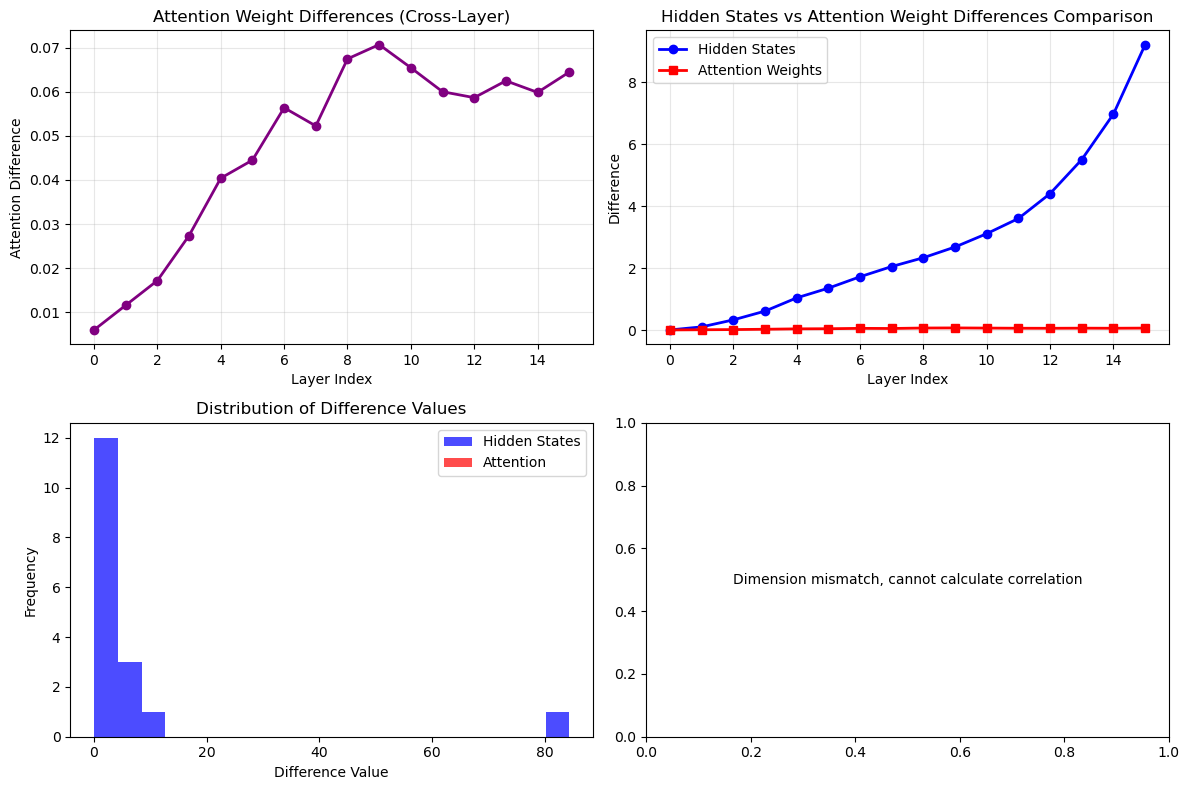


=== 综合分析总结 ===
Hidden States平均差异: 7.616979
注意力权重平均差异: 0.047793
Hidden States差异最大层: Layer 16
注意力差异最大层: Layer 9

=== 模型微调影响分析 ===
早期层(前1/3)平均差异: 0.418822
中间层(中1/3)平均差异: 2.212109
后期层(后1/3)平均差异: 19.020312
→ 微调主要影响模型的后期层，这是典型的fine-tuning模式


In [28]:
# Visualize attention weight differences
plt.figure(figsize=(12, 8))

# Subplot 1: Attention differences across layers
plt.subplot(2, 2, 1)
layers = range(len(attention_diffs))
plt.plot(layers, attention_diffs, 'purple', marker='o', linewidth=2, markersize=6)
plt.xlabel('Layer Index')
plt.ylabel('Attention Difference')
plt.title('Attention Weight Differences (Cross-Layer)')
plt.grid(True, alpha=0.3)

# Subplot 2: Hidden states vs Attention differences comparison
plt.subplot(2, 2, 2)
plt.plot(layers, mean_diffs[:len(attention_diffs)], 'b-o', label='Hidden States', linewidth=2)
plt.plot(layers, attention_diffs, 'r-s', label='Attention Weights', linewidth=2)
plt.xlabel('Layer Index')
plt.ylabel('Difference')
plt.title('Hidden States vs Attention Weight Differences Comparison')
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 3: Difference distribution histogram
plt.subplot(2, 2, 3)
plt.hist(mean_diffs, bins=20, alpha=0.7, label='Hidden States', color='blue')
plt.hist(attention_diffs, bins=20, alpha=0.7, label='Attention', color='red')
plt.xlabel('Difference Value')
plt.ylabel('Frequency')
plt.title('Distribution of Difference Values')
plt.legend()

# Subplot 4: Correlation analysis
plt.subplot(2, 2, 4)
if len(mean_diffs) == len(attention_diffs):
    plt.scatter(mean_diffs, attention_diffs, alpha=0.7, s=60)
    plt.xlabel('Hidden States Difference')
    plt.ylabel('Attention Difference')
    plt.title('Hidden States vs Attention Weight Differences Correlation')
    
    # Add correlation coefficient
    correlation = np.corrcoef(mean_diffs, attention_diffs)[0, 1]
    plt.text(0.05, 0.95, f'Correlation: {correlation:.4f}', 
             transform=plt.gca().transAxes, bbox=dict(boxstyle="round", facecolor='wheat'))
else:
    plt.text(0.5, 0.5, 'Dimension mismatch, cannot calculate correlation', 
             transform=plt.gca().transAxes, ha='center', va='center')

plt.tight_layout()
plt.show()

# 输出总结分析
print("\n=== 综合分析总结 ===")
print(f"Hidden States平均差异: {np.mean(mean_diffs):.6f}")
print(f"注意力权重平均差异: {np.mean(attention_diffs):.6f}")
print(f"Hidden States差异最大层: Layer {np.argmax(mean_diffs)}")
print(f"注意力差异最大层: Layer {np.argmax(attention_diffs)}")

if len(mean_diffs) == len(attention_diffs):
    correlation = np.corrcoef(mean_diffs, attention_diffs)[0, 1]
    print(f"Hidden States与注意力差异的相关性: {correlation:.4f}")
    
    if correlation > 0.7:
        print("→ 强正相关: Hidden States和注意力权重的变化高度一致")
    elif correlation > 0.3:
        print("→ 中等正相关: Hidden States和注意力权重的变化有一定关联")
    elif correlation < -0.3:
        print("→ 负相关: Hidden States和注意力权重的变化方向相反")
    else:
        print("→ 弱相关: Hidden States和注意力权重的变化关联性较弱")

print("\n=== 模型微调影响分析 ===")
early_layers_diff = np.mean(mean_diffs[:len(mean_diffs)//3])
middle_layers_diff = np.mean(mean_diffs[len(mean_diffs)//3:2*len(mean_diffs)//3])
late_layers_diff = np.mean(mean_diffs[2*len(mean_diffs)//3:])

print(f"早期层(前1/3)平均差异: {early_layers_diff:.6f}")
print(f"中间层(中1/3)平均差异: {middle_layers_diff:.6f}")
print(f"后期层(后1/3)平均差异: {late_layers_diff:.6f}")

if late_layers_diff > early_layers_diff:
    print("→ 微调主要影响模型的后期层，这是典型的fine-tuning模式")
else:
    print("→ 微调对早期层影响更大，可能存在较强的表示学习变化")

In [29]:
def analyze_relative_magnitude_changes(ft_model, vanilla_model, tokenizer, data_samples, max_samples=5):
    """
    分析 ft 模型相对于原模型的 hidden states 变化的 L2 范数与原模型层输出本身 L2 范数的相对大小变化
    """
    ft_model.eval()
    vanilla_model.eval()
    
    relative_changes = []
    vanilla_magnitudes = []
    change_magnitudes = []
    
    print(f"Analyzing relative magnitude changes for {min(max_samples, len(data_samples))} samples...")
    
    with torch.no_grad():
        for idx, item in enumerate(data_samples[:max_samples]):
            print(f"Processing sample {idx + 1}/{min(max_samples, len(data_samples))}")
            
            # Prepare input
            prompt = item['prompt']
            inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=512, add_special_tokens=False)
            inputs = {k: v.to(ft_model.device) for k, v in inputs.items()}
            
            # Get hidden states
            ft_outputs = ft_model(**inputs, output_hidden_states=True)
            vanilla_outputs = vanilla_model(**inputs, output_hidden_states=True)
            
            ft_hidden_states = ft_outputs.hidden_states
            vanilla_hidden_states = vanilla_outputs.hidden_states
            
            # Calculate magnitudes for this sample
            sample_relative_changes = []
            sample_vanilla_magnitudes = []
            sample_change_magnitudes = []
            
            for layer_idx in range(len(ft_hidden_states)):
                # Original model layer output L2 norm
                vanilla_magnitude = torch.norm(vanilla_hidden_states[layer_idx], dim=-1).mean().cpu().item()
                
                # Change magnitude (L2 norm of difference)
                change_magnitude = torch.norm(
                    ft_hidden_states[layer_idx] - vanilla_hidden_states[layer_idx], 
                    dim=-1
                ).mean().cpu().item()
                
                # Relative change ratio
                relative_change = change_magnitude / (vanilla_magnitude + 1e-8)
                
                sample_relative_changes.append(relative_change)
                sample_vanilla_magnitudes.append(vanilla_magnitude)
                sample_change_magnitudes.append(change_magnitude)
            
            relative_changes.append(sample_relative_changes)
            vanilla_magnitudes.append(sample_vanilla_magnitudes)
            change_magnitudes.append(sample_change_magnitudes)
    
    # Convert to numpy arrays
    relative_changes = np.array(relative_changes)
    vanilla_magnitudes = np.array(vanilla_magnitudes)
    change_magnitudes = np.array(change_magnitudes)
    
    # Calculate statistics
    mean_relative_changes = np.mean(relative_changes, axis=0)
    std_relative_changes = np.std(relative_changes, axis=0)
    mean_vanilla_magnitudes = np.mean(vanilla_magnitudes, axis=0)
    mean_change_magnitudes = np.mean(change_magnitudes, axis=0)
    
    return (relative_changes, mean_relative_changes, std_relative_changes, 
            mean_vanilla_magnitudes, mean_change_magnitudes)

# Execute relative magnitude analysis
(rel_changes, mean_rel_changes, std_rel_changes, 
 mean_vanilla_mags, mean_change_mags) = analyze_relative_magnitude_changes(
    ft_model, vanilla_model, tokenizer, forget_data, max_samples=5
)

Analyzing relative magnitude changes for 5 samples...
Processing sample 1/5
Processing sample 2/5
Processing sample 3/5
Processing sample 4/5
Processing sample 5/5


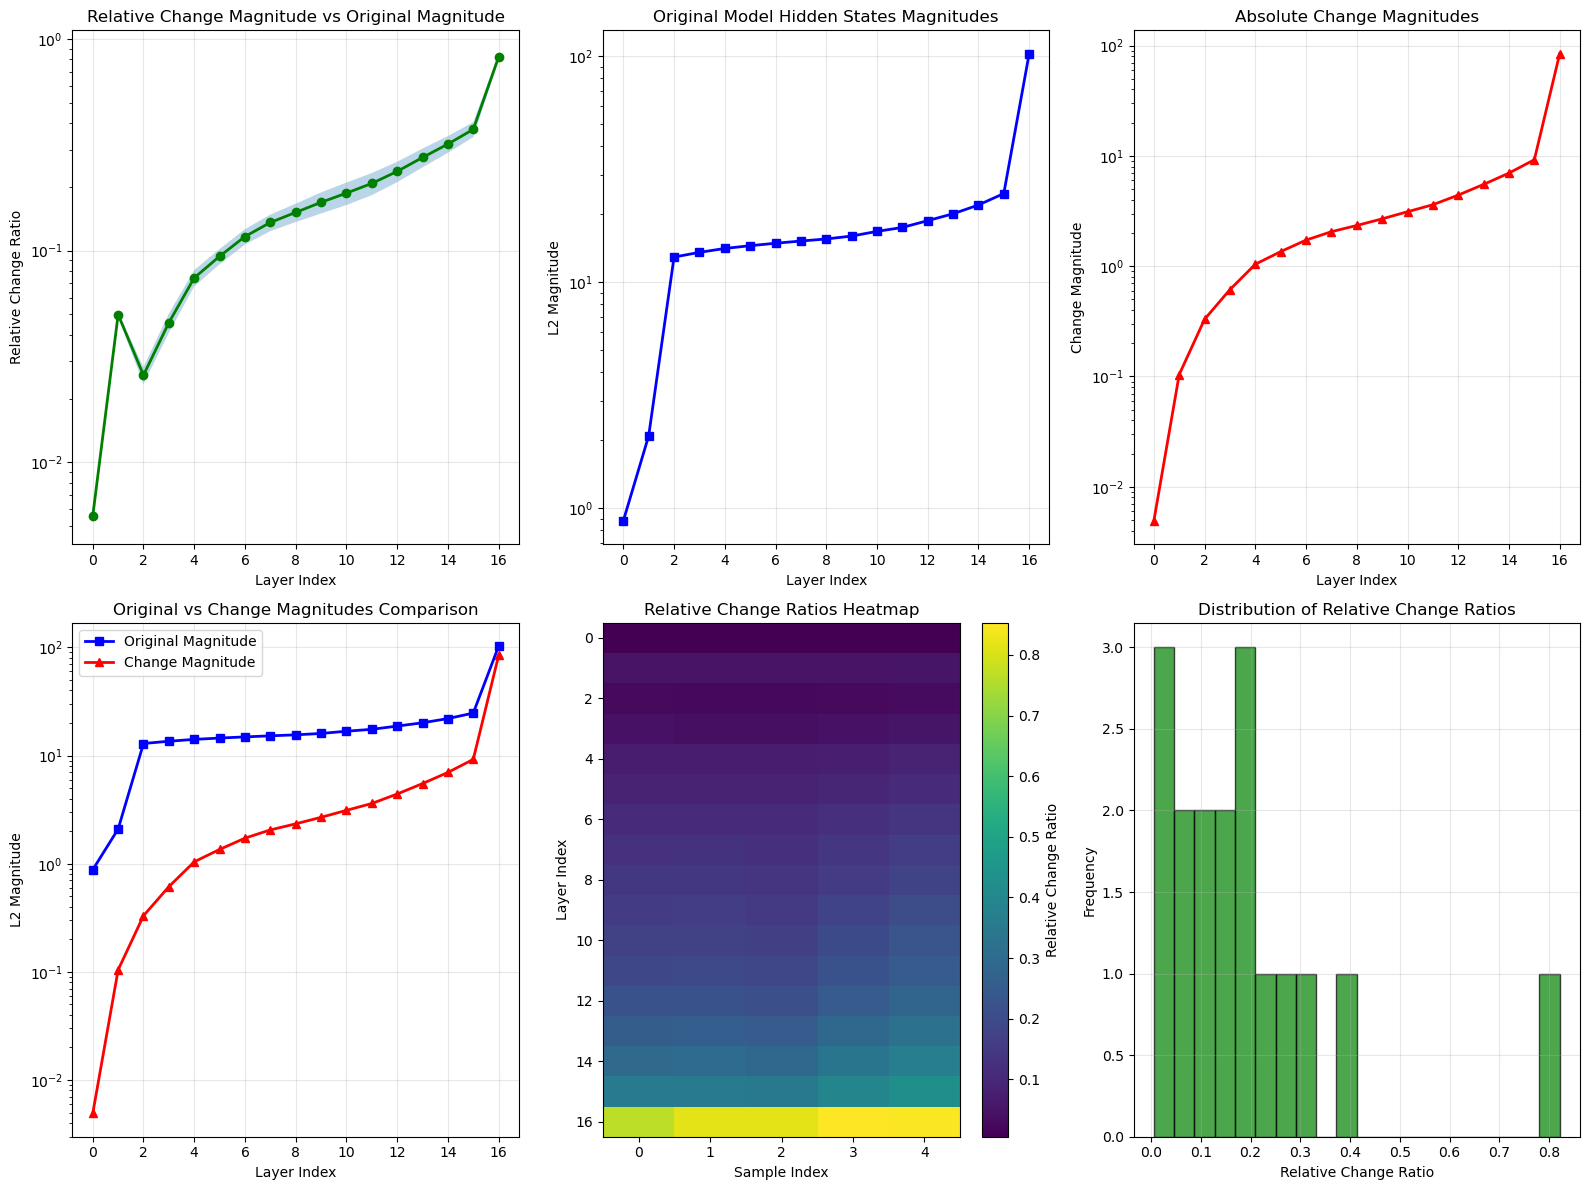


=== Relative Magnitude Change Analysis ===
Average relative change ratio: 0.193417
Maximum relative change ratio: 0.821187 (Layer 16)
Minimum relative change ratio: 0.005578 (Layer 0)
Standard deviation of relative changes: 0.186718

Layers with significant relative changes (> mean + 2*std = 0.566853):
  Layer 16: 0.821187

Correlation Analysis:
  Original magnitude vs Change magnitude: 0.9834
  Original magnitude vs Relative change: 0.9326
  → Strong positive correlation: Layers with larger original magnitudes show larger relative changes

=== Layer-wise Relative Change Analysis ===
Layer  0: Original=0.8801, Change=0.004911, Relative=0.005578
Layer  4: Original=14.1219, Change=1.041211, Relative=0.074320
Layer  8: Original=15.5578, Change=2.338672, Relative=0.151488
Layer 12: Original=18.7469, Change=4.410547, Relative=0.236594
Layer 16: Original=102.7500, Change=84.387500, Relative=0.821187

High relative change layers (top 25%): [np.int64(13), np.int64(14), np.int64(15), np.int64(

In [30]:
# Visualize relative magnitude changes
plt.figure(figsize=(16, 12))

# Subplot 1: Relative change ratios across layers
plt.subplot(2, 3, 1)
layers = range(len(mean_rel_changes))
plt.plot(layers, mean_rel_changes, 'g-o', linewidth=2, markersize=6)
plt.fill_between(layers, mean_rel_changes - std_rel_changes, mean_rel_changes + std_rel_changes, alpha=0.3)
plt.xlabel('Layer Index')
plt.ylabel('Relative Change Ratio')
plt.title('Relative Change Magnitude vs Original Magnitude')
plt.grid(True, alpha=0.3)
plt.yscale('log')  # Log scale for better visualization

# Subplot 2: Original model magnitudes
plt.subplot(2, 3, 2)
plt.plot(layers, mean_vanilla_mags, 'b-s', linewidth=2, markersize=6)
plt.xlabel('Layer Index')
plt.ylabel('L2 Magnitude')
plt.title('Original Model Hidden States Magnitudes')
plt.grid(True, alpha=0.3)
plt.yscale('log')

# Subplot 3: Change magnitudes
plt.subplot(2, 3, 3)
plt.plot(layers, mean_change_mags, 'r-^', linewidth=2, markersize=6)
plt.xlabel('Layer Index')
plt.ylabel('Change Magnitude')
plt.title('Absolute Change Magnitudes')
plt.grid(True, alpha=0.3)
plt.yscale('log')

# Subplot 4: Comparison of magnitudes
plt.subplot(2, 3, 4)
plt.plot(layers, mean_vanilla_mags, 'b-s', label='Original Magnitude', linewidth=2)
plt.plot(layers, mean_change_mags, 'r-^', label='Change Magnitude', linewidth=2)
plt.xlabel('Layer Index')
plt.ylabel('L2 Magnitude')
plt.title('Original vs Change Magnitudes Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log')

# Subplot 5: Relative change heatmap
plt.subplot(2, 3, 5)
im = plt.imshow(rel_changes.T, aspect='auto', cmap='viridis')
plt.xlabel('Sample Index')
plt.ylabel('Layer Index')
plt.title('Relative Change Ratios Heatmap')
plt.colorbar(im, label='Relative Change Ratio')

# Subplot 6: Distribution of relative changes
plt.subplot(2, 3, 6)
plt.hist(mean_rel_changes, bins=20, alpha=0.7, color='green', edgecolor='black')
plt.xlabel('Relative Change Ratio')
plt.ylabel('Frequency')
plt.title('Distribution of Relative Change Ratios')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print analysis results
print("\n=== Relative Magnitude Change Analysis ===")
print(f"Average relative change ratio: {np.mean(mean_rel_changes):.6f}")
print(f"Maximum relative change ratio: {np.max(mean_rel_changes):.6f} (Layer {np.argmax(mean_rel_changes)})")
print(f"Minimum relative change ratio: {np.min(mean_rel_changes):.6f} (Layer {np.argmin(mean_rel_changes)})")
print(f"Standard deviation of relative changes: {np.std(mean_rel_changes):.6f}")

# Identify layers with significant relative changes
significant_threshold = np.mean(mean_rel_changes) + 2 * np.std(mean_rel_changes)
significant_layers = np.where(mean_rel_changes > significant_threshold)[0]

print(f"\nLayers with significant relative changes (> mean + 2*std = {significant_threshold:.6f}):")
for layer in significant_layers:
    print(f"  Layer {layer}: {mean_rel_changes[layer]:.6f}")

# Analyze the relationship between original magnitude and change
correlation_mag_change = np.corrcoef(mean_vanilla_mags, mean_change_mags)[0, 1]
correlation_mag_relative = np.corrcoef(mean_vanilla_mags, mean_rel_changes)[0, 1]

print(f"\nCorrelation Analysis:")
print(f"  Original magnitude vs Change magnitude: {correlation_mag_change:.4f}")
print(f"  Original magnitude vs Relative change: {correlation_mag_relative:.4f}")

if correlation_mag_relative < -0.5:
    print("  → Strong negative correlation: Layers with larger original magnitudes show smaller relative changes")
elif correlation_mag_relative > 0.5:
    print("  → Strong positive correlation: Layers with larger original magnitudes show larger relative changes")
else:
    print("  → Weak correlation between original magnitude and relative change")

# Layer-wise interpretation
print(f"\n=== Layer-wise Relative Change Analysis ===")
for i in range(len(mean_rel_changes)):
    if i % 4 == 0 or i == len(mean_rel_changes) - 1:  # Print every 4th layer and last layer
        print(f"Layer {i:2d}: Original={mean_vanilla_mags[i]:.4f}, Change={mean_change_mags[i]:.6f}, "
              f"Relative={mean_rel_changes[i]:.6f}")

# Categorize layers by relative change
high_change_threshold = np.percentile(mean_rel_changes, 75)
low_change_threshold = np.percentile(mean_rel_changes, 25)

high_change_layers = np.where(mean_rel_changes > high_change_threshold)[0]
low_change_layers = np.where(mean_rel_changes < low_change_threshold)[0]

print(f"\nHigh relative change layers (top 25%): {list(high_change_layers)}")
print(f"Low relative change layers (bottom 25%): {list(low_change_layers)}")
print(f"Average relative change in high-change layers: {np.mean(mean_rel_changes[high_change_layers]):.6f}")
print(f"Average relative change in low-change layers: {np.mean(mean_rel_changes[low_change_layers]):.6f}")

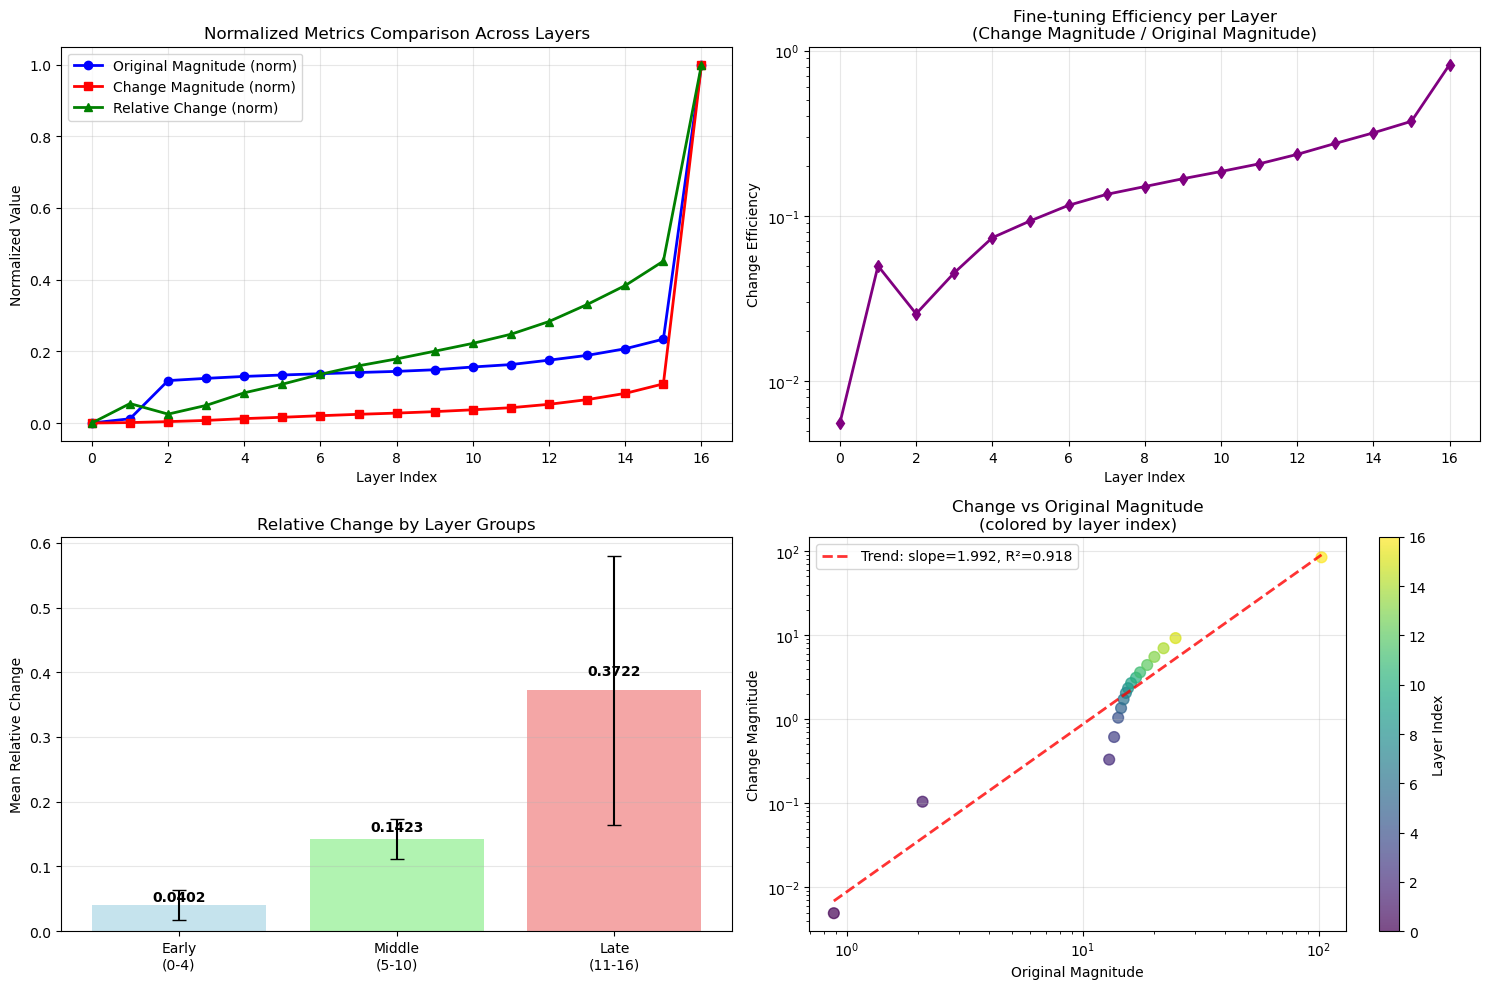


=== Advanced Relative Change Pattern Analysis ===

Layer Group Analysis:
Early layers (0-4): Mean relative change = 0.040239 ± 0.023208
Middle layers (5-10): Mean relative change = 0.142265 ± 0.031162
Late layers (11-16): Mean relative change = 0.372217 ± 0.207898

Kruskal-Wallis test between layer groups: H=14.2353, p=0.000811
→ Significant difference between layer groups

Outlier Analysis (using IQR method):
High outlier layers: [np.int64(16)]
Low outlier layers: []

Magnitude Scaling Analysis:
Log-log slope between original and change magnitudes: 1.9924
→ Super-linear scaling: Larger layers change disproportionately more

Efficiency Analysis:
Most efficient layer (highest relative change): Layer 16 (0.821187)
Least efficient layer (lowest relative change): Layer 0 (0.005578)
Efficiency ratio (max/min): 147.23x


In [31]:
# Advanced relative change pattern analysis
plt.figure(figsize=(15, 10))

# Subplot 1: Normalized comparison of all metrics
plt.subplot(2, 2, 1)
# Normalize all metrics to [0, 1] for comparison
norm_vanilla_mags = (mean_vanilla_mags - np.min(mean_vanilla_mags)) / (np.max(mean_vanilla_mags) - np.min(mean_vanilla_mags))
norm_change_mags = (mean_change_mags - np.min(mean_change_mags)) / (np.max(mean_change_mags) - np.min(mean_change_mags))
norm_rel_changes = (mean_rel_changes - np.min(mean_rel_changes)) / (np.max(mean_rel_changes) - np.min(mean_rel_changes))

plt.plot(layers, norm_vanilla_mags, 'b-o', label='Original Magnitude (norm)', linewidth=2)
plt.plot(layers, norm_change_mags, 'r-s', label='Change Magnitude (norm)', linewidth=2)
plt.plot(layers, norm_rel_changes, 'g-^', label='Relative Change (norm)', linewidth=2)
plt.xlabel('Layer Index')
plt.ylabel('Normalized Value')
plt.title('Normalized Metrics Comparison Across Layers')
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 2: Relative change efficiency (change per unit of original magnitude)
plt.subplot(2, 2, 2)
efficiency = mean_change_mags / (mean_vanilla_mags + 1e-8)  # Same as relative change
plt.plot(layers, efficiency, 'purple', marker='d', linewidth=2, markersize=6)
plt.xlabel('Layer Index')
plt.ylabel('Change Efficiency')
plt.title('Fine-tuning Efficiency per Layer\n(Change Magnitude / Original Magnitude)')
plt.grid(True, alpha=0.3)
plt.yscale('log')

# Subplot 3: Layer grouping analysis
plt.subplot(2, 2, 3)
# Group layers into early, middle, late
num_layers = len(mean_rel_changes)
early_layers = list(range(0, num_layers//3))
middle_layers = list(range(num_layers//3, 2*num_layers//3))
late_layers = list(range(2*num_layers//3, num_layers))

group_means = [
    np.mean(mean_rel_changes[early_layers]),
    np.mean(mean_rel_changes[middle_layers]),
    np.mean(mean_rel_changes[late_layers])
]
group_stds = [
    np.std(mean_rel_changes[early_layers]),
    np.std(mean_rel_changes[middle_layers]),
    np.std(mean_rel_changes[late_layers])
]

groups = ['Early\n(0-{})'.format(num_layers//3-1), 
          'Middle\n({}-{})'.format(num_layers//3, 2*num_layers//3-1),
          'Late\n({}-{})'.format(2*num_layers//3, num_layers-1)]

bars = plt.bar(groups, group_means, yerr=group_stds, capsize=5, alpha=0.7, 
               color=['lightblue', 'lightgreen', 'lightcoral'])
plt.ylabel('Mean Relative Change')
plt.title('Relative Change by Layer Groups')
plt.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, mean_val in zip(bars, group_means):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + bar.get_height()*0.05,
             f'{mean_val:.4f}', ha='center', va='bottom', fontweight='bold')

# Subplot 4: Change magnitude vs original magnitude scatter
plt.subplot(2, 2, 4)
plt.scatter(mean_vanilla_mags, mean_change_mags, alpha=0.7, s=60, c=layers, cmap='viridis')
plt.xlabel('Original Magnitude')
plt.ylabel('Change Magnitude')
plt.title('Change vs Original Magnitude\n(colored by layer index)')
plt.colorbar(label='Layer Index')
plt.grid(True, alpha=0.3)
plt.loglog()  # Log-log scale

# Add trend line
from scipy import stats
slope, intercept, r_value, p_value, std_err = stats.linregress(np.log(mean_vanilla_mags), np.log(mean_change_mags))
trend_x = np.logspace(np.log10(np.min(mean_vanilla_mags)), np.log10(np.max(mean_vanilla_mags)), 100)
trend_y = np.exp(intercept) * (trend_x ** slope)
plt.plot(trend_x, trend_y, 'r--', alpha=0.8, linewidth=2, 
         label=f'Trend: slope={slope:.3f}, R²={r_value**2:.3f}')
plt.legend()

plt.tight_layout()
plt.show()

# Advanced statistical analysis
print("\n=== Advanced Relative Change Pattern Analysis ===")

# Calculate layer-wise relative change patterns
print(f"\nLayer Group Analysis:")
print(f"Early layers ({early_layers[0]}-{early_layers[-1]}): Mean relative change = {group_means[0]:.6f} ± {group_stds[0]:.6f}")
print(f"Middle layers ({middle_layers[0]}-{middle_layers[-1]}): Mean relative change = {group_means[1]:.6f} ± {group_stds[1]:.6f}")
print(f"Late layers ({late_layers[0]}-{late_layers[-1]}): Mean relative change = {group_means[2]:.6f} ± {group_stds[2]:.6f}")

# Statistical significance test between groups
from scipy.stats import kruskal
h_stat, p_val = kruskal(mean_rel_changes[early_layers], 
                       mean_rel_changes[middle_layers], 
                       mean_rel_changes[late_layers])
print(f"\nKruskal-Wallis test between layer groups: H={h_stat:.4f}, p={p_val:.6f}")
if p_val < 0.05:
    print("→ Significant difference between layer groups")
else:
    print("→ No significant difference between layer groups")

# Identify outlier layers
q1, q3 = np.percentile(mean_rel_changes, [25, 75])
iqr = q3 - q1
outlier_threshold_high = q3 + 1.5 * iqr
outlier_threshold_low = q1 - 1.5 * iqr

outlier_layers_high = np.where(mean_rel_changes > outlier_threshold_high)[0]
outlier_layers_low = np.where(mean_rel_changes < outlier_threshold_low)[0]

print(f"\nOutlier Analysis (using IQR method):")
print(f"High outlier layers: {list(outlier_layers_high)}")
print(f"Low outlier layers: {list(outlier_layers_low)}")

# Magnitude scaling analysis
print(f"\nMagnitude Scaling Analysis:")
print(f"Log-log slope between original and change magnitudes: {slope:.4f}")
if abs(slope - 1.0) < 0.1:
    print("→ Linear scaling: Change magnitude proportional to original magnitude")
elif slope > 1.0:
    print("→ Super-linear scaling: Larger layers change disproportionately more")
elif slope < 1.0:
    print("→ Sub-linear scaling: Larger layers change disproportionately less")

# Efficiency analysis
max_efficiency_layer = np.argmax(mean_rel_changes)
min_efficiency_layer = np.argmin(mean_rel_changes)
print(f"\nEfficiency Analysis:")
print(f"Most efficient layer (highest relative change): Layer {max_efficiency_layer} ({mean_rel_changes[max_efficiency_layer]:.6f})")
print(f"Least efficient layer (lowest relative change): Layer {min_efficiency_layer} ({mean_rel_changes[min_efficiency_layer]:.6f})")
print(f"Efficiency ratio (max/min): {mean_rel_changes[max_efficiency_layer]/mean_rel_changes[min_efficiency_layer]:.2f}x")

In [ ]:
import torch
torch.optim.adamw